## Nettoyage & Visualisation

### Import des modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import pointbiserialr, chi2_contingency
import warnings
warnings.filterwarnings("ignore")


### Chargement des données

In [6]:
app_train_clean5 = joblib.load("../data/app_train_clean5.joblib")
app_test_clean5 = joblib.load("../data/app_test_clean5.joblib")


In [7]:
def check_columns(df_ref, df_test, name_ref="train", name_test="test"):
    cols_ref = set(df_ref.columns)
    cols_test = set(df_test.columns)

    missing = cols_ref - cols_test
    extra = cols_test - cols_ref

    print(f"--- Vérification colonnes : {name_test} vs {name_ref} ---")
    print(f"Colonnes attendues : {len(cols_ref)}")
    print(f"Colonnes trouvées  : {len(cols_test)}")

    if missing:
        print("\n❌ Colonnes manquantes dans", name_test, ":")
        for c in sorted(missing):
            print("   -", c)
    else:
        print("\n✔️ Aucune colonne manquante")

    if extra:
        print("\n⚠️ Colonnes supplémentaires dans", name_test, ":")
        for c in sorted(extra):
            print("   -", c)
    else:
        print("\n✔️ Aucune colonne supplémentaire")

    print("\n--------------------------------------------\n")


In [8]:
# Check des colonnes entre train et test
check_columns(app_train_clean5, app_test_clean5, name_ref="train", name_test="test")

--- Vérification colonnes : test vs train ---
Colonnes attendues : 606
Colonnes trouvées  : 605

❌ Colonnes manquantes dans test :
   - TARGET

✔️ Aucune colonne supplémentaire

--------------------------------------------



In [9]:
# Vérifier que les colonnes entre train et test sont bien identiques mis à part "TARGET"
train_cols = set(app_train_clean5.columns) - {"TARGET"}
test_cols = set(app_test_clean5.columns)

diff_train = train_cols - test_cols
diff_test = test_cols - train_cols

print("Colonnes dans train mais pas dans test :", diff_train)
print("Colonnes dans test mais pas dans train :", diff_test)


Colonnes dans train mais pas dans test : set()
Colonnes dans test mais pas dans train : set()


### Suppression des variables constantes

In [10]:
# Vérification des colonnes constantes
pd.set_option("display.max_rows", None)
data = [app_train_clean5, app_test_clean5]
name = ["Train_clean", "Test_clean"]
for nom, df in zip(name, data):
    print(f"\n--- Nombre de valeurs uniques - {nom} ---")
    constantes = df.nunique()
    constantes = constantes[constantes == 1]
    display(constantes)



--- Nombre de valeurs uniques - Train_clean ---


PREV_NAME_GOODS_CATEGORY_House Construction    1
CC_SK_DPD_min                                  1
CC_SK_DPD_DEF_min                              1
dtype: int64


--- Nombre de valeurs uniques - Test_clean ---


FLAG_DOCUMENT_2                                                    1
FLAG_DOCUMENT_10                                                   1
FLAG_DOCUMENT_12                                                   1
FLAG_DOCUMENT_13                                                   1
FLAG_DOCUMENT_14                                                   1
FLAG_DOCUMENT_15                                                   1
FLAG_DOCUMENT_16                                                   1
FLAG_DOCUMENT_17                                                   1
FLAG_DOCUMENT_19                                                   1
FLAG_DOCUMENT_20                                                   1
FLAG_DOCUMENT_21                                                   1
BUREAU_CREDIT_TYPE_Interbank credit                                1
BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending)    1
BUREAU_CREDIT_TYPE_Mobile operator loan                            1
PREV_NAME_GOODS_CATEGORY_Animals  

In [11]:
# Supprimer, les variables constantes o quasi constantes depuis le train: fonction qui supprime les variables qui ne prennent qu'une seule valeur pour tous les clients
# ou dont 98% des clients ont la même valeur
def supprimer_colonnes_constantes(df_train, df_test, threshold=1):
    nunique_train = df_train.nunique()
    cols_a_supp = nunique_train[nunique_train <= threshold].index.tolist()

    print("Colonnes supprimées :", cols_a_supp)

    df_train_clean = df_train.drop(columns=cols_a_supp)
    df_test_clean = df_test.drop(columns=cols_a_supp, errors="ignore")

    return df_train_clean, df_test_clean, cols_a_supp



In [12]:
app_train_clean6, app_test_clean6, dropped_cols = supprimer_colonnes_constantes(app_train_clean5, app_test_clean5)
print(app_train_clean6.shape, app_test_clean6.shape)


Colonnes supprimées : ['PREV_NAME_GOODS_CATEGORY_House Construction', 'CC_SK_DPD_min', 'CC_SK_DPD_DEF_min']
(307511, 603) (48744, 602)


In [13]:
# Check des colonnes entre train et test
check_columns(app_train_clean6, app_test_clean6, name_ref="train", name_test="test")

--- Vérification colonnes : test vs train ---
Colonnes attendues : 603
Colonnes trouvées  : 602

❌ Colonnes manquantes dans test :
   - TARGET

✔️ Aucune colonne supplémentaire

--------------------------------------------



In [14]:
train_cols = set(app_train_clean6.columns) - {"TARGET"}
test_cols = set(app_test_clean6.columns)

diff_train = train_cols - test_cols
diff_test = test_cols - train_cols

print("Colonnes dans train mais pas dans test :", diff_train)
print("Colonnes dans test mais pas dans train :", diff_test)

Colonnes dans train mais pas dans test : set()
Colonnes dans test mais pas dans train : set()


### Suppressions des variables redondantes
- Suppression dans le train <> supprimer les variables trop correlées entre elles (>=70%); et si égalité conserver celles les plus correlées avec la cible **TARGET**
- Puis adaptation dans le test

In [15]:
# Sélection de 120 colonnes les plus pertinentes mannuellement

colonnes_selectionnees = [

    # Colonnes obligatoires
    "SK_ID_CURR", "TARGET", "NAME_CONTRACT_TYPE", "CODE_GENDER",
    "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE",
    "CNT_CHILDREN", "AMT_INCOME_TOTAL",

    # EXT_SOURCE
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",

    # Socio-démographiques & stabilité
    "AMT_GOODS_PRICE", "REGION_POPULATION_RELATIVE", "DAYS_BIRTH",
    "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH",
    "OWN_CAR_AGE", "REGION_RATING_CLIENT_W_CITY",
    "HOUR_APPR_PROCESS_START", "DAYS_LAST_PHONE_CHANGE",
    "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",

    # Logement / immeuble
    "ELEVATORS_AVG", "BASEMENTAREA_AVG", "YEARS_BEGINEXPLUATATION_MEDI",
    "YEARS_BUILD_MEDI", "COMMONAREA_MEDI", "ENTRANCES_AVG",
    "FLOORSMAX_AVG", "LANDAREA_MEDI", "NONLIVINGAPARTMENTS_AVG",
    "NONLIVINGAREA_AVG",

    # BUREAU
    "BUREAU_DAYS_CREDIT_mean", "BUREAU_DAYS_CREDIT_max",
    "BUREAU_DAYS_CREDIT_min", "BUREAU_DAYS_CREDIT_ENDDATE_mean",
    "BUREAU_DAYS_CREDIT_ENDDATE_max", "BUREAU_DAYS_CREDIT_ENDDATE_min",
    "BUREAU_DAYS_CREDIT_ENDDATE_sum", "BUREAU_DAYS_ENDDATE_FACT_sum",
    "BUREAU_DAYS_ENDDATE_FACT_max", "BUREAU_CREDIT_DAY_OVERDUE_mean",
    "BUREAU_CREDIT_DAY_OVERDUE_sum", "BUREAU_AMT_CREDIT_SUM_mean",
    "BUREAU_AMT_CREDIT_SUM_min", "BUREAU_AMT_CREDIT_SUM_sum",
    "BUREAU_AMT_CREDIT_SUM_DEBT_max", "BUREAU_AMT_CREDIT_SUM_DEBT_sum",
    "BUREAU_AMT_CREDIT_SUM_LIMIT_mean", "BUREAU_AMT_CREDIT_SUM_LIMIT_sum",
    "BUREAU_AMT_CREDIT_SUM_OVERDUE_max", "BUREAU_AMT_CREDIT_SUM_OVERDUE_sum",
    "BUREAU_AMT_ANNUITY_mean", "BUREAU_CREDIT_ACTIVE_NUNIQUE",
    "BUREAU_CREDIT_TYPE_NUNIQUE", "BUREAU_STATUS_NUNIQUE",
    "BUREAU_MONTHS_BALANCE_max",

    # PREVIOUS APPLICATIONS
    "PREV_AMT_ANNUITY_mean", "PREV_AMT_ANNUITY_min",
    "PREV_AMT_APPLICATION_min", "PREV_AMT_DOWN_PAYMENT_sum",
    "PREV_RATE_DOWN_PAYMENT_max", "PREV_RATE_DOWN_PAYMENT_sum",
    "PREV_RATE_INTEREST_PRIMARY_max", "PREV_RATE_INTEREST_PRIMARY_sum",
    "PREV_RATE_INTEREST_PRIVILEGED_max", "PREV_CNT_PAYMENT_max",
    "PREV_CNT_PAYMENT_min", "PREV_DAYS_FIRST_DRAWING_mean",
    "PREV_DAYS_FIRST_DRAWING_max", "PREV_DAYS_FIRST_DUE_min",
    "PREV_DAYS_LAST_DUE_mean", "PREV_DAYS_LAST_DUE_min",
    "PREV_DAYS_TERMINATION_mean", "PREV_NFLAG_INSURED_ON_APPROVAL_sum",
    "PREV_NAME_PRODUCT_TYPE_NUNIQUE", "PREV_NAME_CLIENT_TYPE_NUNIQUE",
    "PREV_NAME_PAYMENT_TYPE_NUNIQUE", "PREV_NAME_SELLER_INDUSTRY_NUNIQUE",
    "PREV_NAME_CONTRACT_STATUS_Refused",
    "PREV_NAME_CONTRACT_STATUS_Unused offer",
    "PREV_NAME_PORTFOLIO_POS",

    # CREDIT CARD
    "CC_UTILIZATION_mean", "CC_UTILIZATION_max", "CC_UTILIZATION_min",
    "CC_AMT_BALANCE_mean", "CC_AMT_CREDIT_LIMIT_ACTUAL_max",
    "CC_AMT_DRAWINGS_CURRENT_mean", "CC_AMT_DRAWINGS_CURRENT_max",
    "CC_AMT_DRAWINGS_CURRENT_min", "CC_AMT_DRAWINGS_ATM_CURRENT_mean",
    "CC_AMT_DRAWINGS_ATM_CURRENT_sum", "CC_CNT_DRAWINGS_ATM_CURRENT_mean",
    "CC_CNT_DRAWINGS_ATM_CURRENT_sum", "CC_AMT_PAYMENT_TOTAL_CURRENT_max",
    "CC_AMT_PAYMENT_CURRENT_min", "CC_SK_DPD_max", "CC_SK_DPD_DEF_max",
    "CC_PAYMENT_RATIO_max", "CC_PAYMENT_RATIO_min",
    "CC_NAME_CONTRACT_STATUS_NUNIQUE", "CC_MONTHS_BALANCE_max",

    # INSTALLMENTS PAYMENTS
    "INST_PAY_AMT_PAYMENT_mean", "INST_PAY_AMT_PAYMENT_sum",
    "INST_PAY_AMT_PAYMENT_min", "INST_PAY_PAYMENT_DELAY_mean",
    "INST_PAY_PAYMENT_DELAY_max", "INST_PAY_PAYMENT_DELAY_min",
    "INST_PAY_PAYMENT_DELAY_sum", "INST_PAY_PAYMENT_RATIO_mean",
    "INST_PAY_PAYMENT_RATIO_min", "INST_PAY_NUM_INSTALMENT_VERSION_mean",

    # POS CASH
    "POS_SK_DPD_mean", "POS_SK_DPD_min", "POS_SK_DPD_DEF_max",
    "POS_SK_DPD_DEF_min", "POS_CNT_INSTALMENT_min",
    "POS_CNT_INSTALMENT_FUTURE_min", "POS_NAME_CONTRACT_STATUS_NUNIQUE",
    "POS_NAME_CONTRACT_STATUS_Approved",
    "POS_NAME_CONTRACT_STATUS_Completed",
    "POS_NAME_CONTRACT_STATUS_Signed"
]

In [16]:
# Fonction de suppression des redondances
def supprimer_variables_redondantes(df, cible, corr_threshold=0.6):

    # Colonnes à protéger (tes 120 colonnes)
    variables_protegees = set(colonnes_selectionnees)

    df_num = df.select_dtypes(include=["float64", "int64"]).drop(columns=["SK_ID_CURR"])
    df_num_clean = df_num.replace([np.inf, -np.inf], np.nan)

    corr = df_num_clean.corr().abs()
    corr_cible = df_num_clean.apply(lambda col: col.corr(cible)).abs()

    variables_a_garder = set()   # <-- SET pour éviter les doublons
    colonnes = set(df_num_clean.columns)

    for col in df_num_clean.columns:

        if col not in colonnes:
            continue

        groupe = set(corr.index[corr[col] >= corr_threshold])

        # Si le groupe contient une variable protégée → garder toutes les protégées du groupe
        if groupe & variables_protegees:
            variables_a_garder |= (groupe & variables_protegees)
            colonnes -= groupe
            continue

        # Sinon logique normale
        col_best = max(groupe, key=lambda x: corr_cible[x])
        variables_a_garder.add(col_best)
        colonnes -= groupe

    # Ajouter les protégées restantes
    variables_a_garder |= (variables_protegees & set(df_num_clean.columns))

    # Retourner une liste propre, sans doublons
    return list(variables_a_garder)


In [17]:
cible = app_train_clean6['TARGET']
variables_a_garder = supprimer_variables_redondantes(app_train_clean6, cible=cible)
print(f"Nombre de colonnes gardées: {len(variables_a_garder)}")
print(variables_a_garder)
print(app_train_clean6.shape)

Nombre de colonnes gardées: 278
['BUREAU_CREDIT_DAY_OVERDUE_mean', 'PREV_DAYS_TERMINATION_mean', 'PREV_NAME_GOODS_CATEGORY_Animals', 'CC_AMT_BALANCE_mean', 'PREV_CNT_PAYMENT_max', 'PREV_NAME_CASH_LOAN_PURPOSE_Buying a used car', 'PREV_CODE_REJECT_REASON_SCO', 'POS_NAME_CONTRACT_STATUS_Signed', 'CC_AMT_INST_MIN_REGULARITY_min', 'CC_CNT_DRAWINGS_ATM_CURRENT_mean', 'PREV_NAME_PAYMENT_TYPE_Non-cash from your account', 'PREV_NAME_SELLER_INDUSTRY_Industry', 'BUREAU_AMT_CREDIT_SUM_DEBT_sum', 'PREV_NAME_CASH_LOAN_PURPOSE_Furniture', 'POS_NAME_CONTRACT_STATUS_Completed', 'PREV_NAME_GOODS_CATEGORY_Homewares', 'PREV_NAME_PRODUCT_TYPE_NUNIQUE', 'POS_CNT_INSTALMENT_FUTURE_min', 'BUREAU_DAYS_ENDDATE_FACT_sum', 'PREV_WEEKDAY_APPR_PROCESS_START_SATURDAY', 'PREV_NAME_YIELD_GROUP_XNA', 'PREV_CODE_REJECT_REASON_SCOFR', 'CC_AMT_DRAWINGS_ATM_CURRENT_mean', 'PREV_NAME_GOODS_CATEGORY_Additional Service', 'BUREAU_STATUS_1', 'BUREAU_CREDIT_TYPE_Microloan', 'PREV_PRODUCT_COMBINATION_POS industry without interes

In [18]:
# Fusion variables non redondantes et variables qualitatives
app_train_qual = app_train_clean6.select_dtypes(include=['object', 'bool', 'string'])
app_train_clean = pd.concat([app_train_clean6['SK_ID_CURR'], app_train_qual, app_train_clean6[variables_a_garder]], axis=1)
app_train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 328 entries, SK_ID_CURR to PREV_DAYS_FIRST_DRAWING_mean
dtypes: bool(33), float64(272), int64(7), object(16)
memory usage: 701.8+ MB


In [19]:
app_train_clean.columns[app_train_clean.columns.duplicated()]


Index([], dtype='object')

In [20]:
app_train_clean.columns.duplicated().sum()

0

In [21]:
# Adapter les variables de "test" avec celles de "train"
col_a_garder_test = []
for col in app_test_clean6.columns:
    if col in app_train_clean.columns:
        col_a_garder_test.append(col) 

print(len(col_a_garder_test))
app_test_clean = app_test_clean6[col_a_garder_test]
print(app_test_clean6.shape, app_test_clean.shape, app_train_clean.shape)
app_test_clean.info()


327
(48744, 602) (48744, 327) (307511, 328)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 327 entries, SK_ID_CURR to POS_NAME_CONTRACT_STATUS_XNA
dtypes: bool(32), float64(272), int64(7), object(16)
memory usage: 111.2+ MB


In [22]:
# Check des colonnes entre train et test
check_columns(app_train_clean, app_test_clean, name_ref="train", name_test="test")

--- Vérification colonnes : test vs train ---
Colonnes attendues : 328
Colonnes trouvées  : 327

❌ Colonnes manquantes dans test :
   - TARGET

✔️ Aucune colonne supplémentaire

--------------------------------------------



In [23]:
train_cols = set(app_train_clean.columns) - {"TARGET"}
test_cols = set(app_test_clean.columns)

diff_train = train_cols - test_cols
diff_test = test_cols - train_cols

print("Colonnes dans train mais pas dans test :", diff_train)
print("Colonnes dans test mais pas dans train :", diff_test)

Colonnes dans train mais pas dans test : set()
Colonnes dans test mais pas dans train : set()


### Gestion des valeurs manquantes
Concrnant les valeurs manquantes, leur gestion fait partie intégrante des **"experiments"** du *MLFlow* à tester afin de voir leur impact sur les métriques et le coût métier


In [24]:
pd.set_option("display.max_rows", None)
print(app_train_clean.shape)
missing_values = app_train_clean.isna().sum().reset_index()
missing_values.columns = ["colonne", "valeurs_manquantes"]  
missing_values["pourcentage"] = (missing_values["valeurs_manquantes"] / app_train_clean.shape[0] * 100).round(1)

missing_values = missing_values[missing_values["pourcentage"] >= 70.0]
missing_values.sort_values("pourcentage", ascending=False, inplace=True) 
missing_values

(307511, 328)


,colonne,valeurs_manquantes,pourcentage
226,PREV_RATE_INTEREST_PRIMARY_max,302902,98.5
258,PREV_RATE_INTEREST_PRIVILEGED_max,302902,98.5
203,CC_PAYMENT_RATIO_min,247875,80.6
277,CC_PAYMENT_RATIO_max,247875,80.6
144,CC_AMT_PAYMENT_CURRENT_min,246451,80.1
59,CC_CNT_DRAWINGS_ATM_CURRENT_mean,246371,80.1
72,CC_AMT_DRAWINGS_ATM_CURRENT_mean,246371,80.1
223,CC_CNT_DRAWINGS_OTHER_CURRENT_mean,246371,80.1
99,CC_CNT_DRAWINGS_ATM_CURRENT_min,246371,80.1
116,CC_CNT_DRAWINGS_OTHER_CURRENT_min,246371,80.1


Concernant les valeurs manquantes, j'ai choisi de les gérer dans le process MLFlow sous forme d'expériences afin de voir leur impact sur les résultats

### Visualisation des distributions

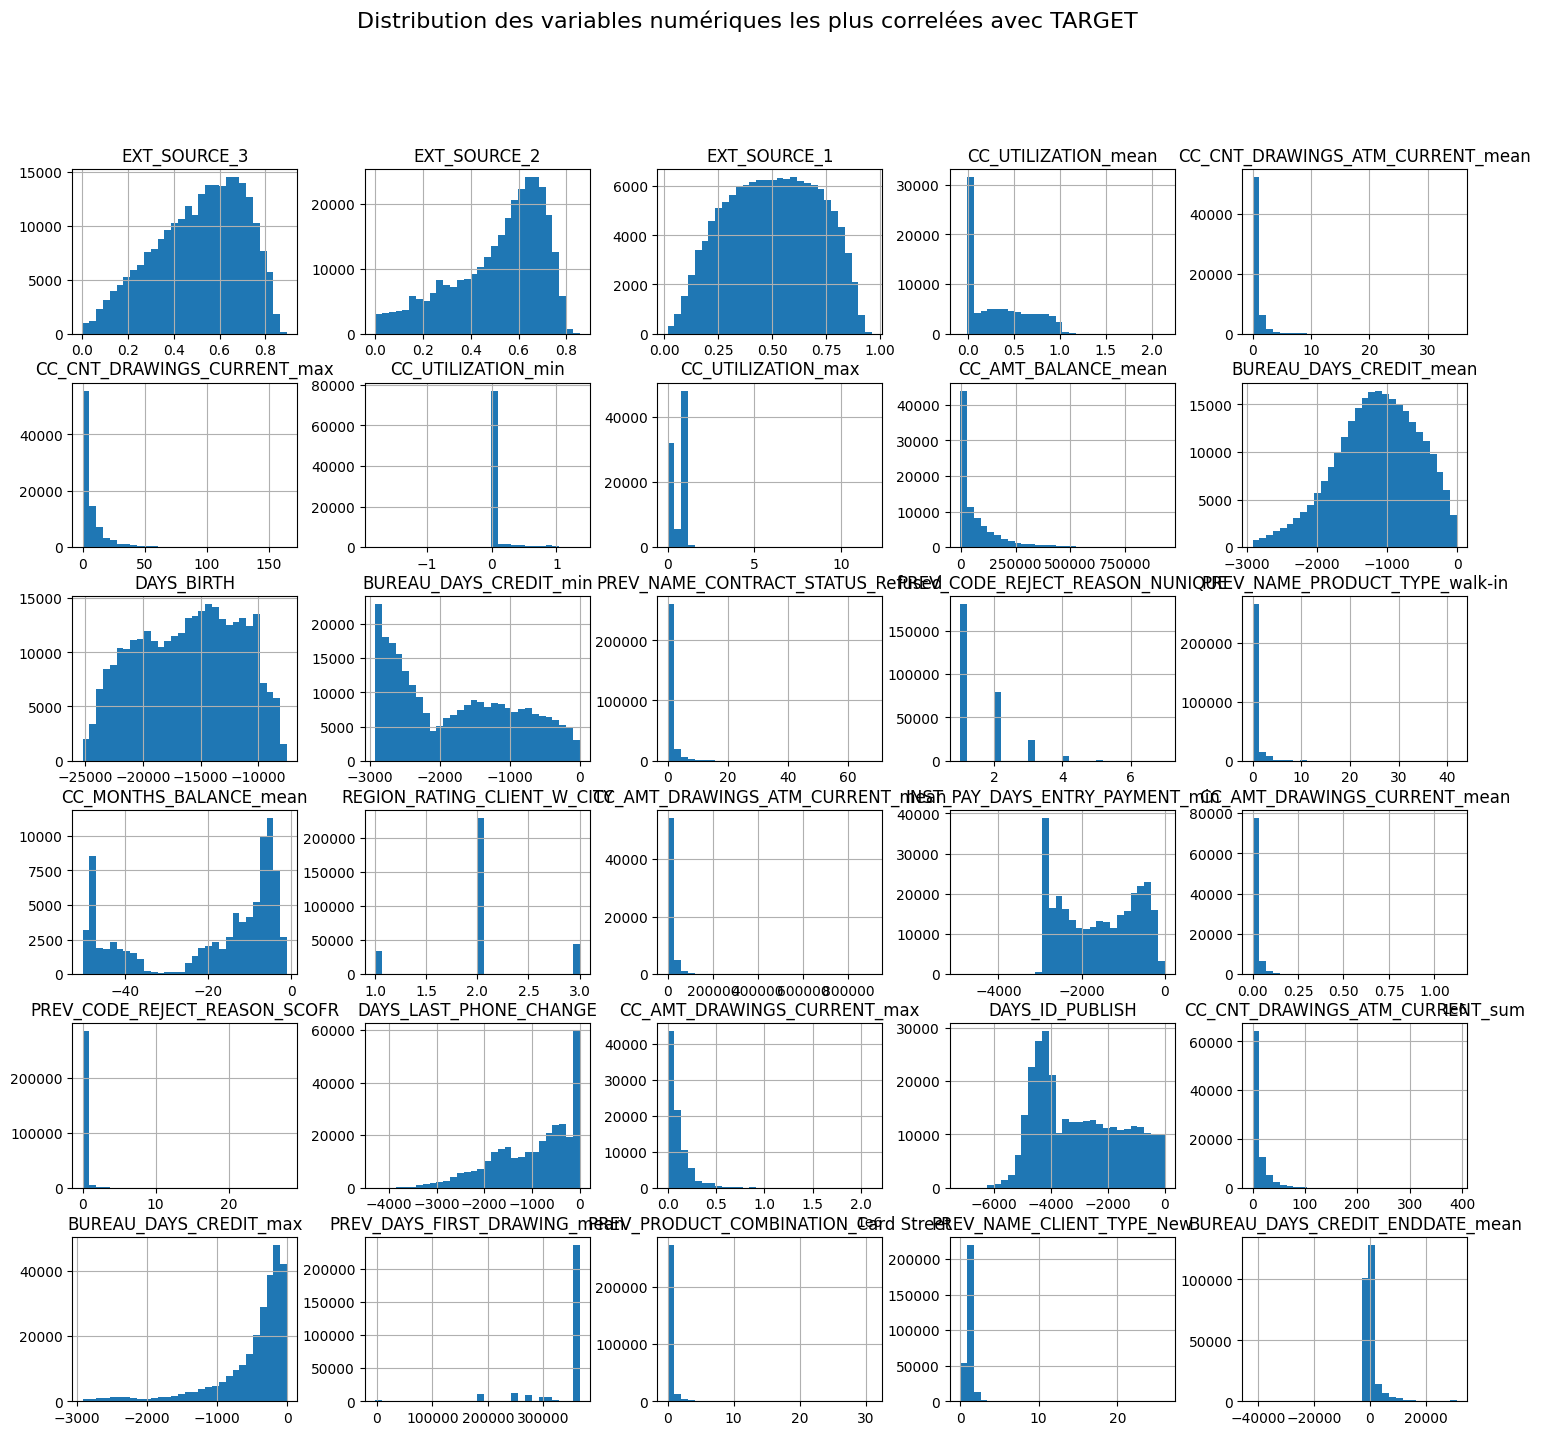

In [25]:
# Visualisation des distributions numériques(int64) et la cible
n=30
df_num = app_train_clean.select_dtypes(include=['int64', 'float64'])
corr_cible = df_num.corrwith(app_train_clean['TARGET']).abs().sort_values(ascending=False)
top_variables = corr_cible.head(n).index # sélection des 30 variables les plus correlée avec la cible hors mis la cible <> pourquoi 30, parce que nous avons plus de 300 variables
                                        # leur affichage sera illisible, donc j'affiche uniquement les variables les plus corrlées avec la cible, 30

df_num_viz = df_num[top_variables]
df_num_viz.head()
df_num_viz.hist(figsize=(18, 16), bins=30)
plt.suptitle(f"Distribution des variables numériques les plus correlées avec TARGET", fontsize=16)
plt.show()

In [26]:
df_num_viz.index.equals(app_train_clean.index)


True

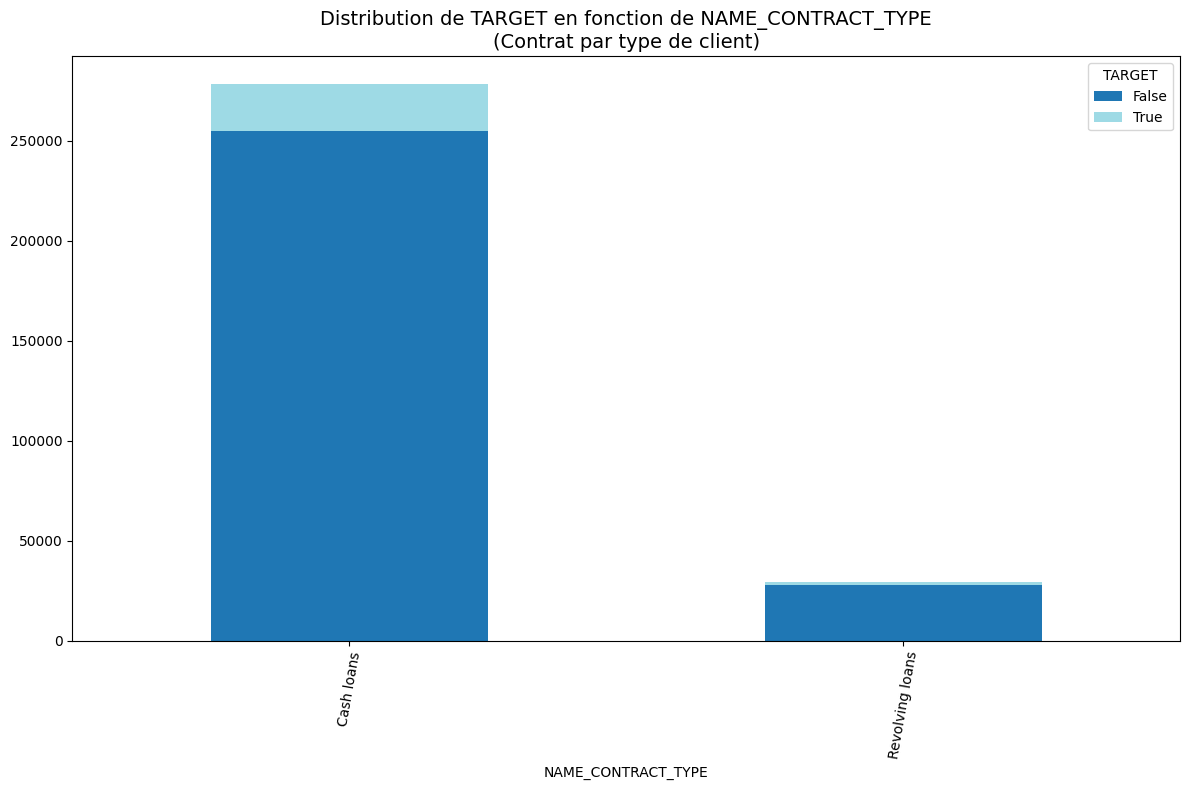

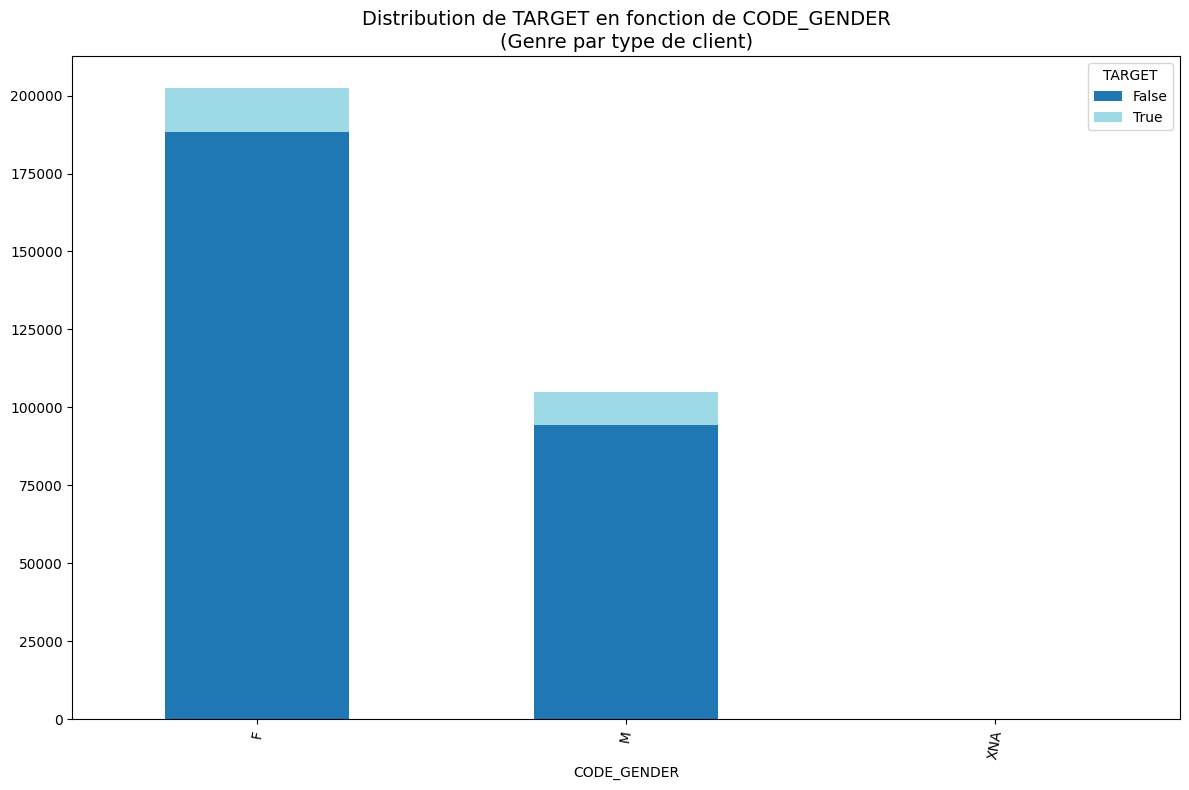

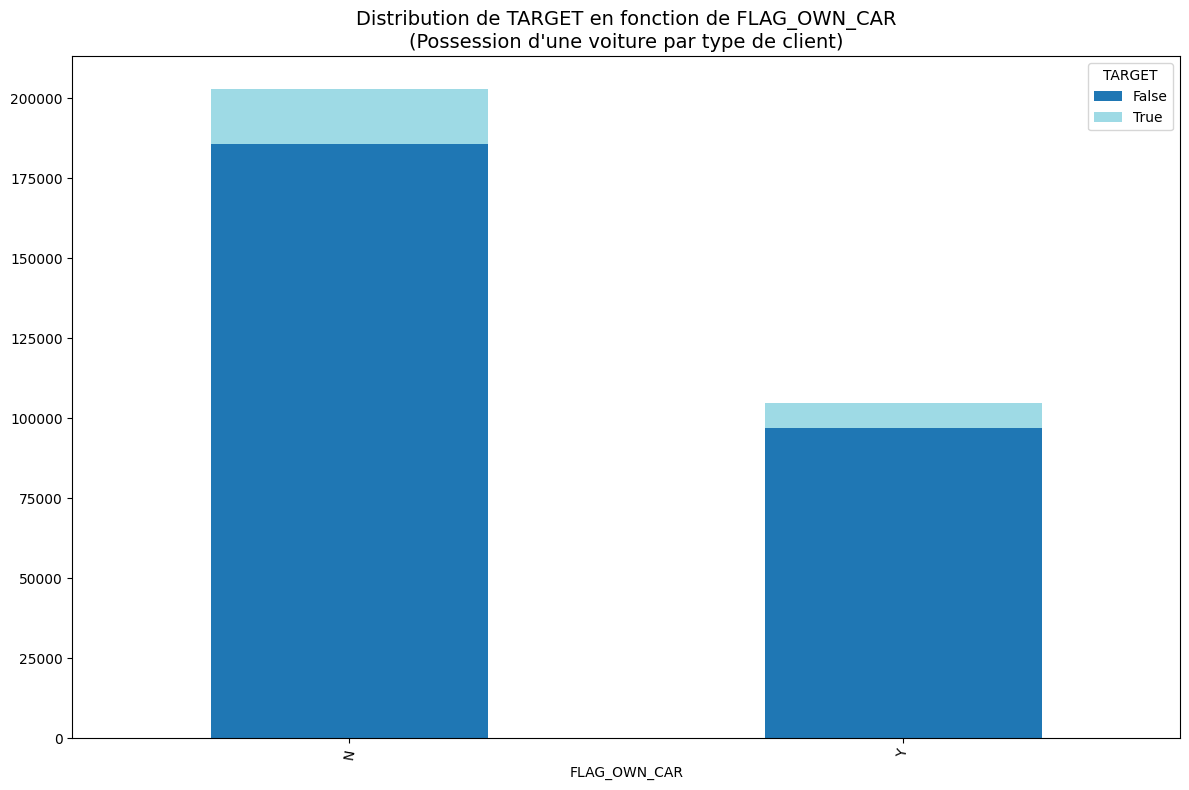

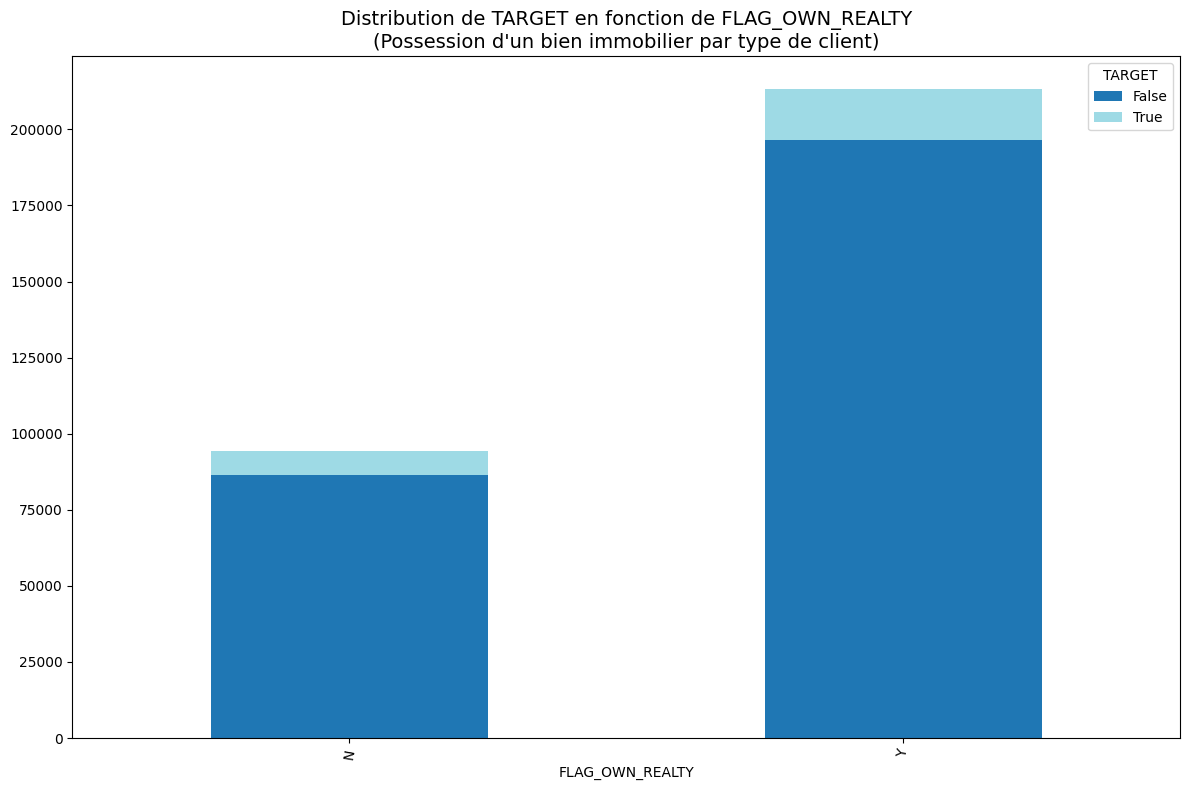

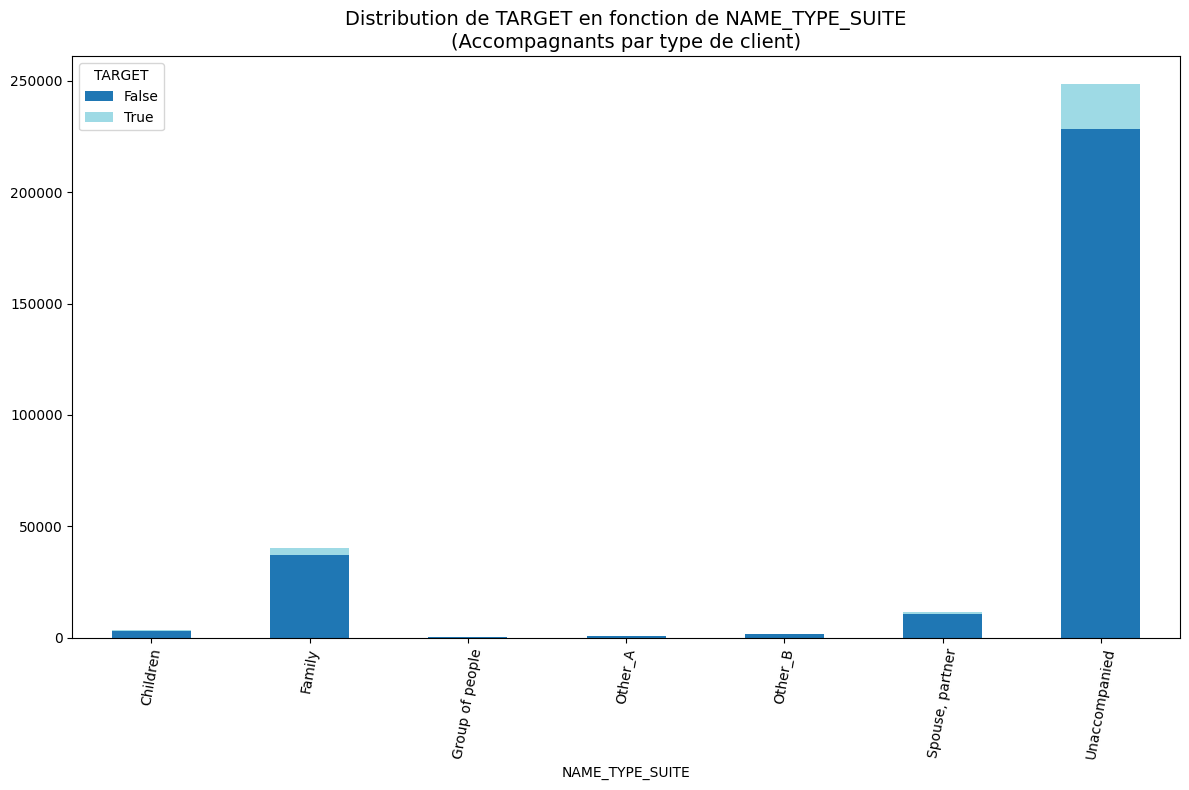

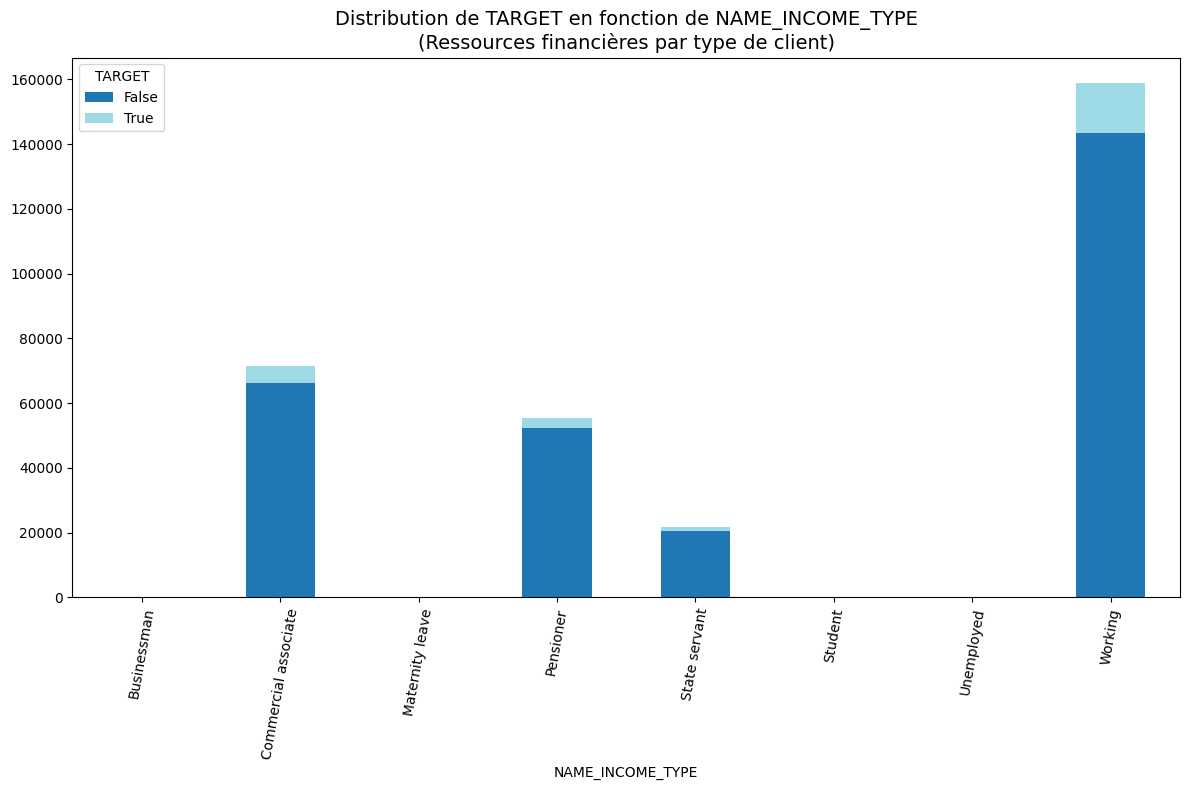

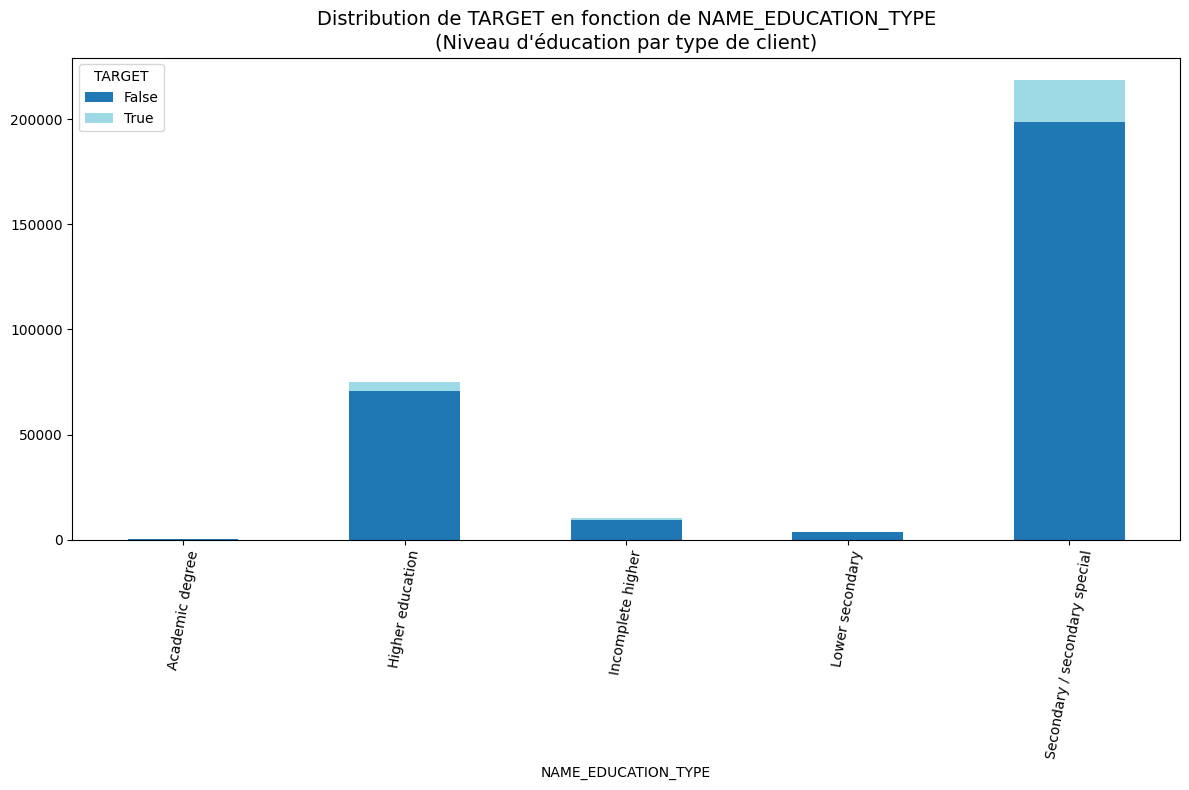

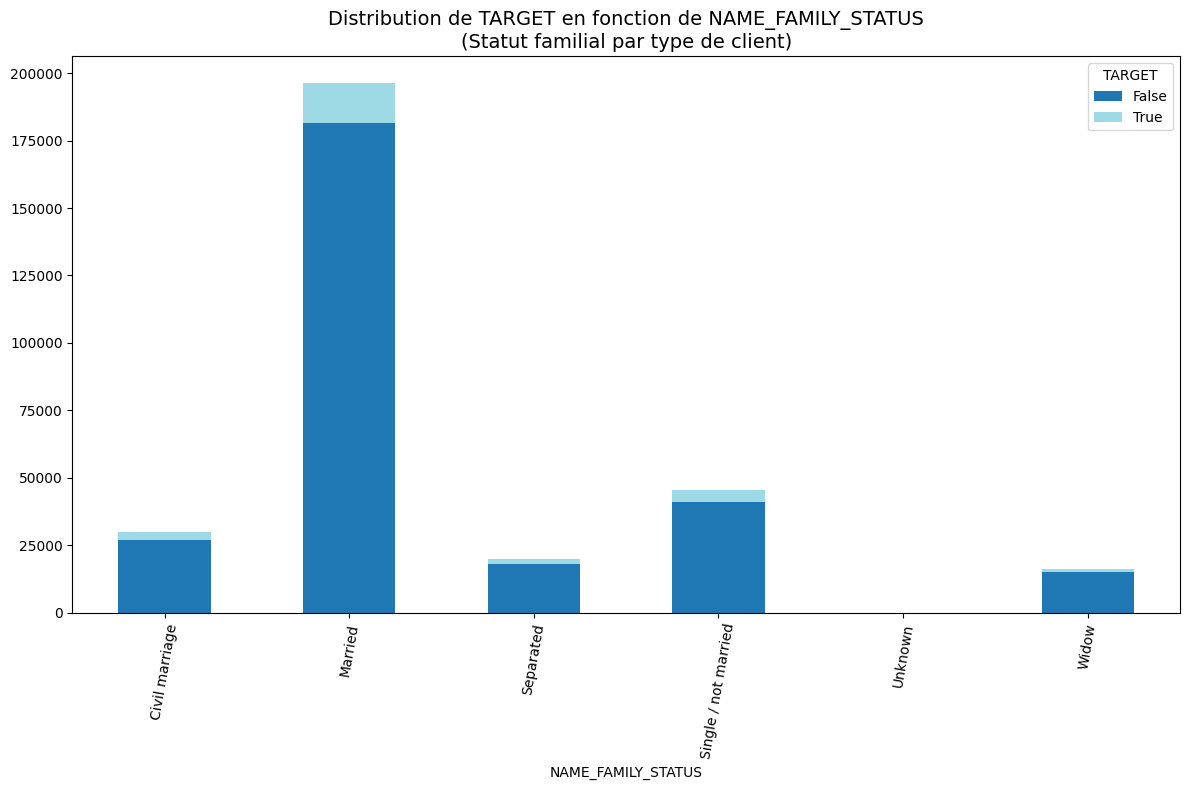

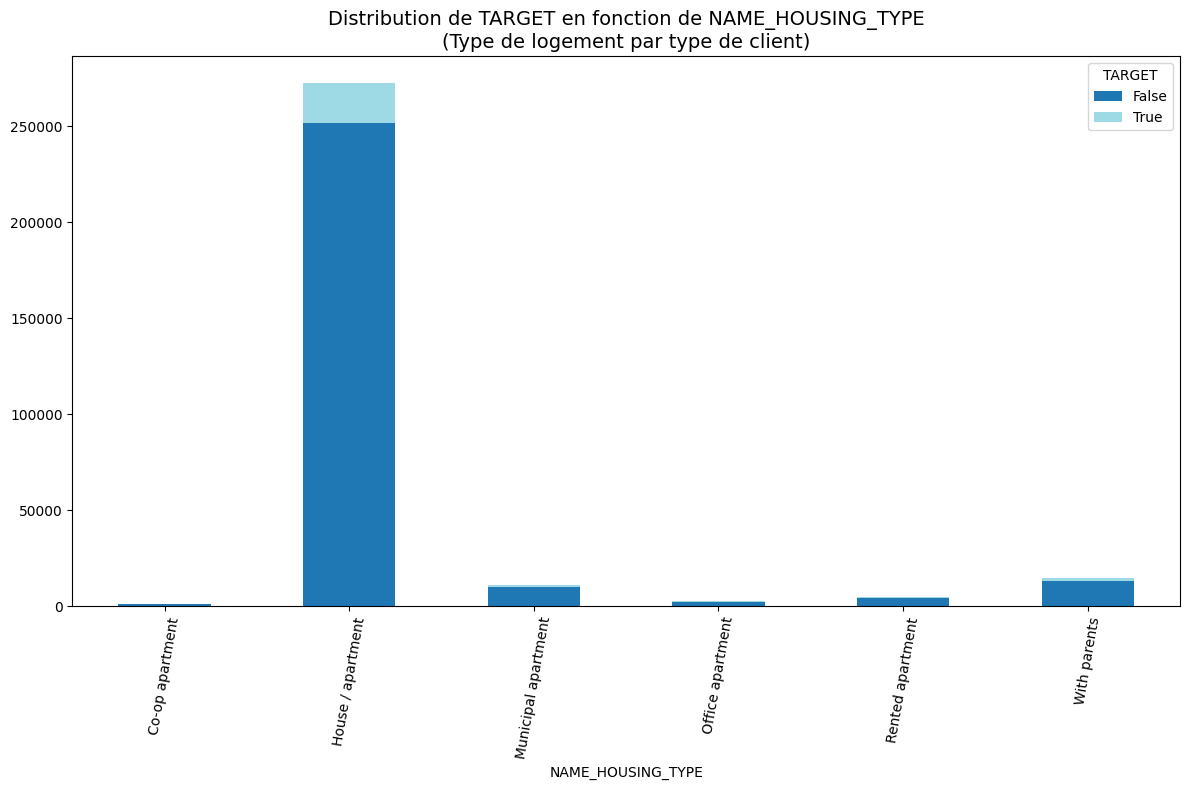

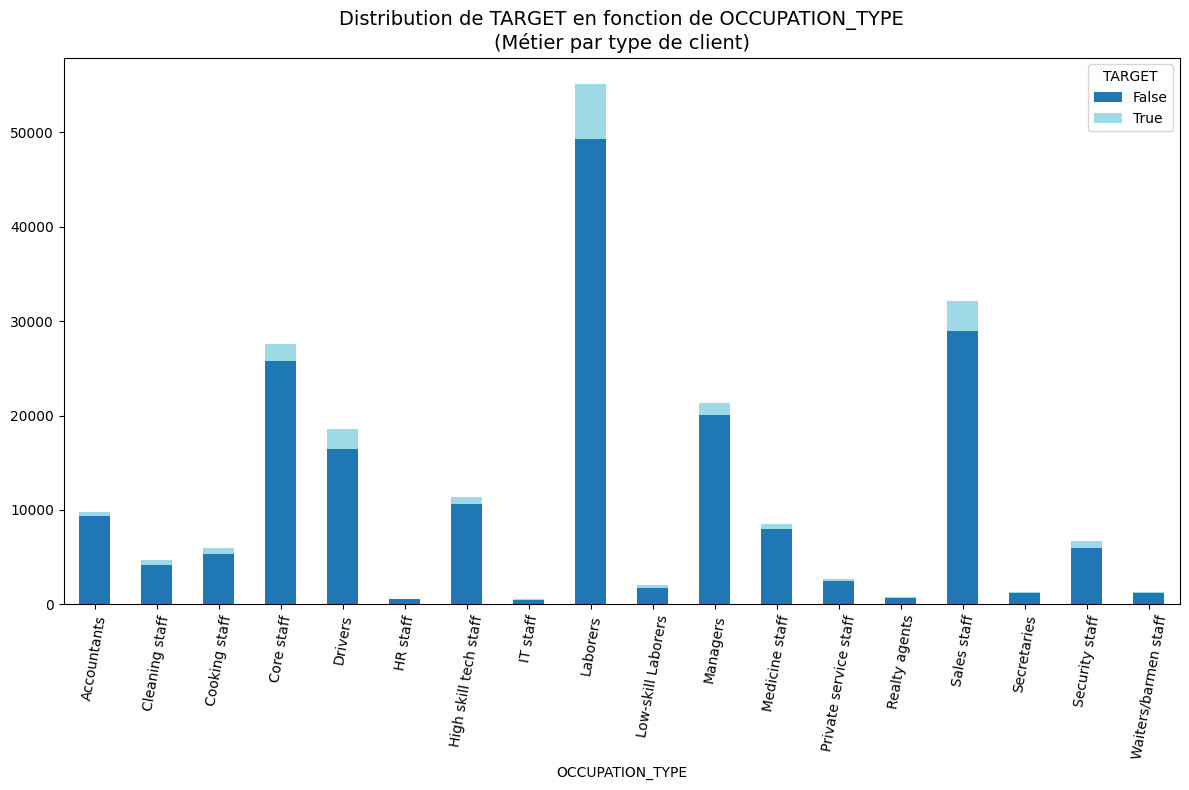

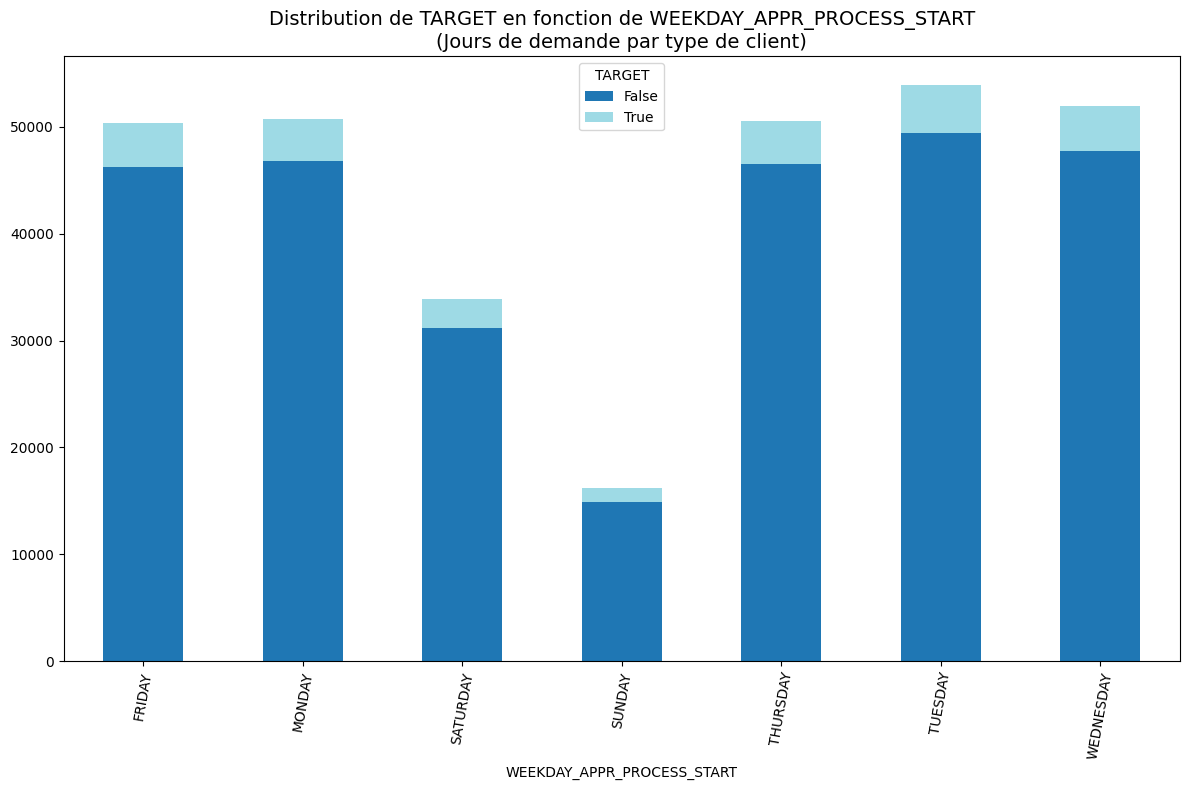

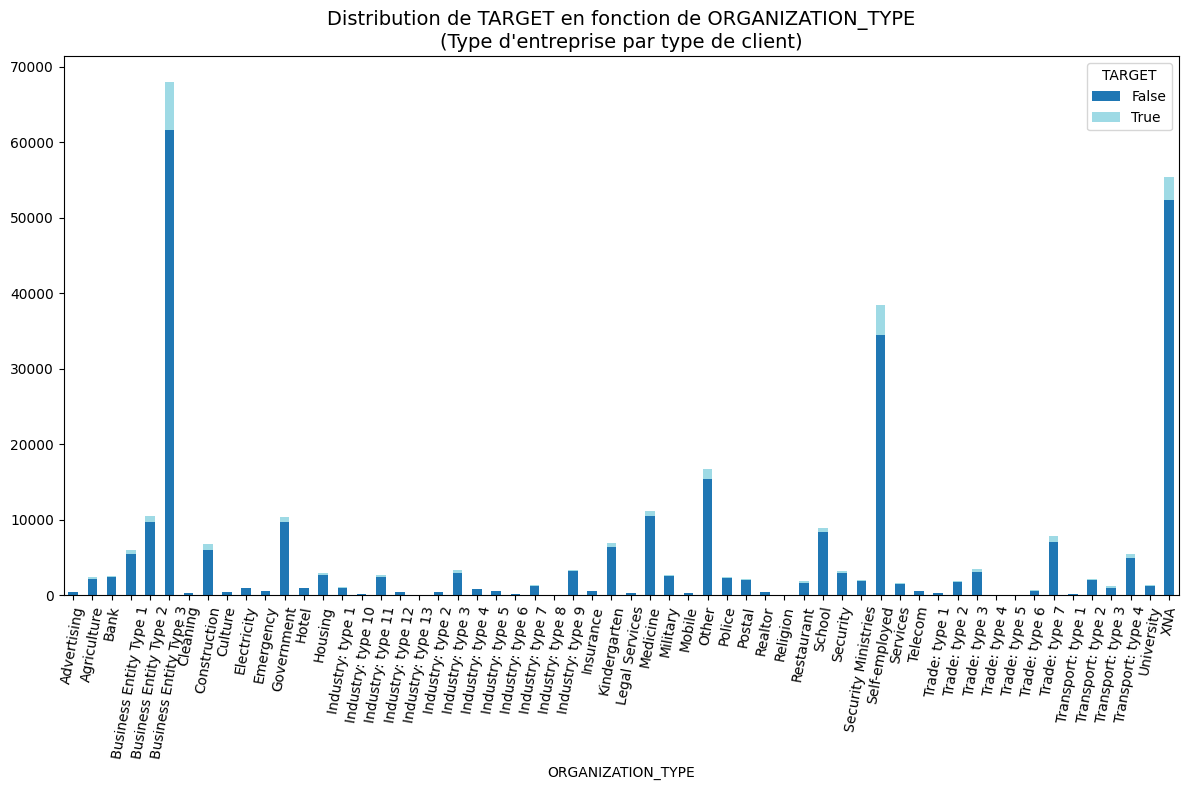

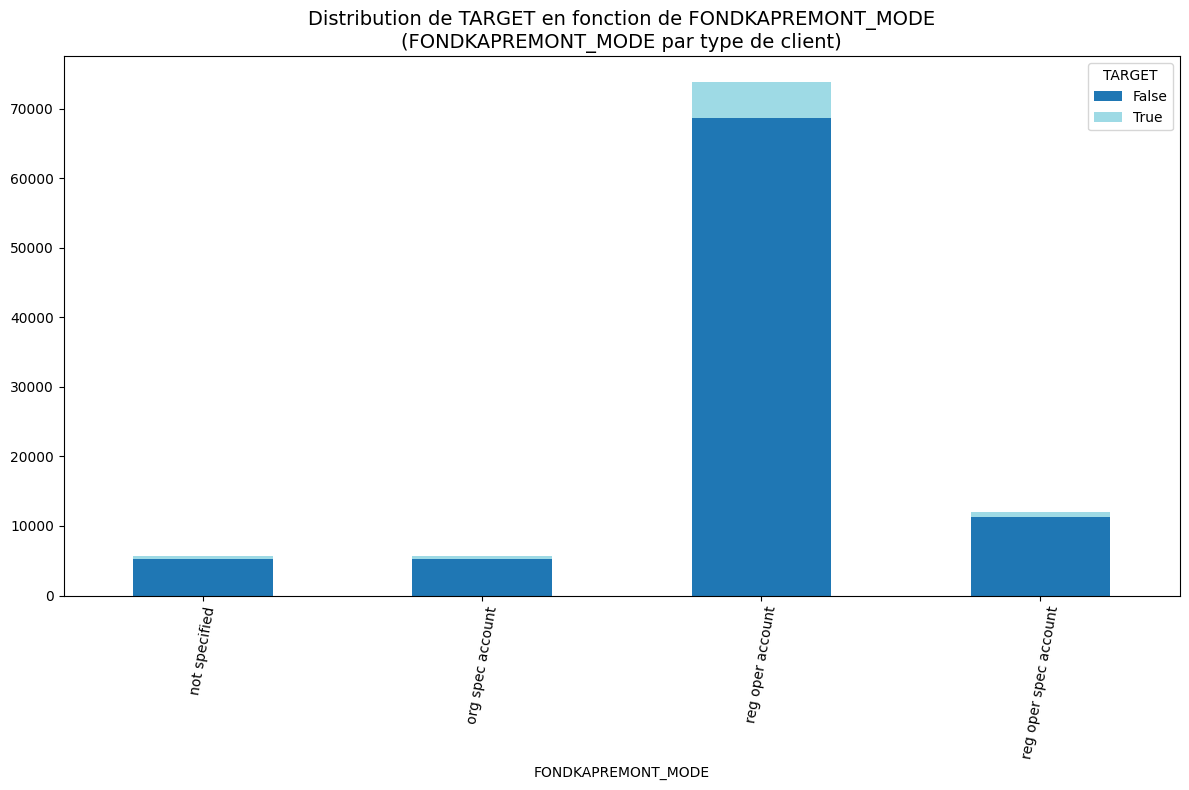

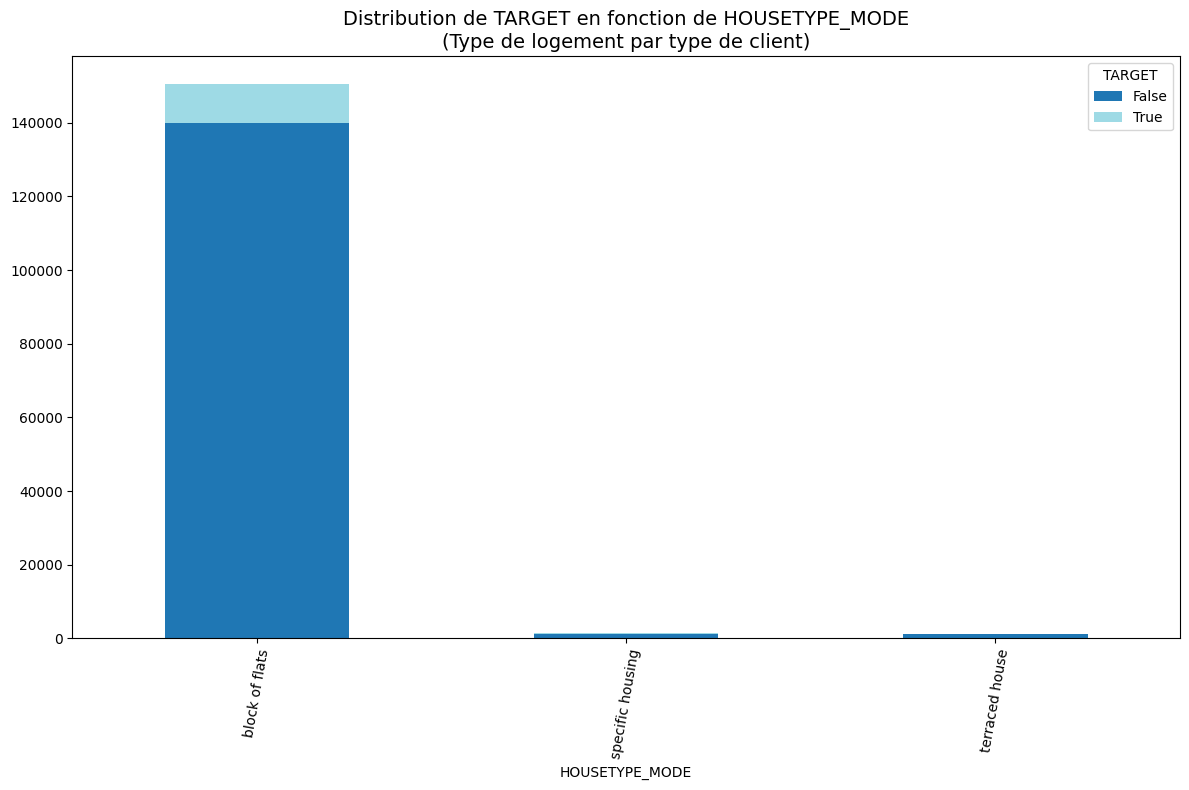

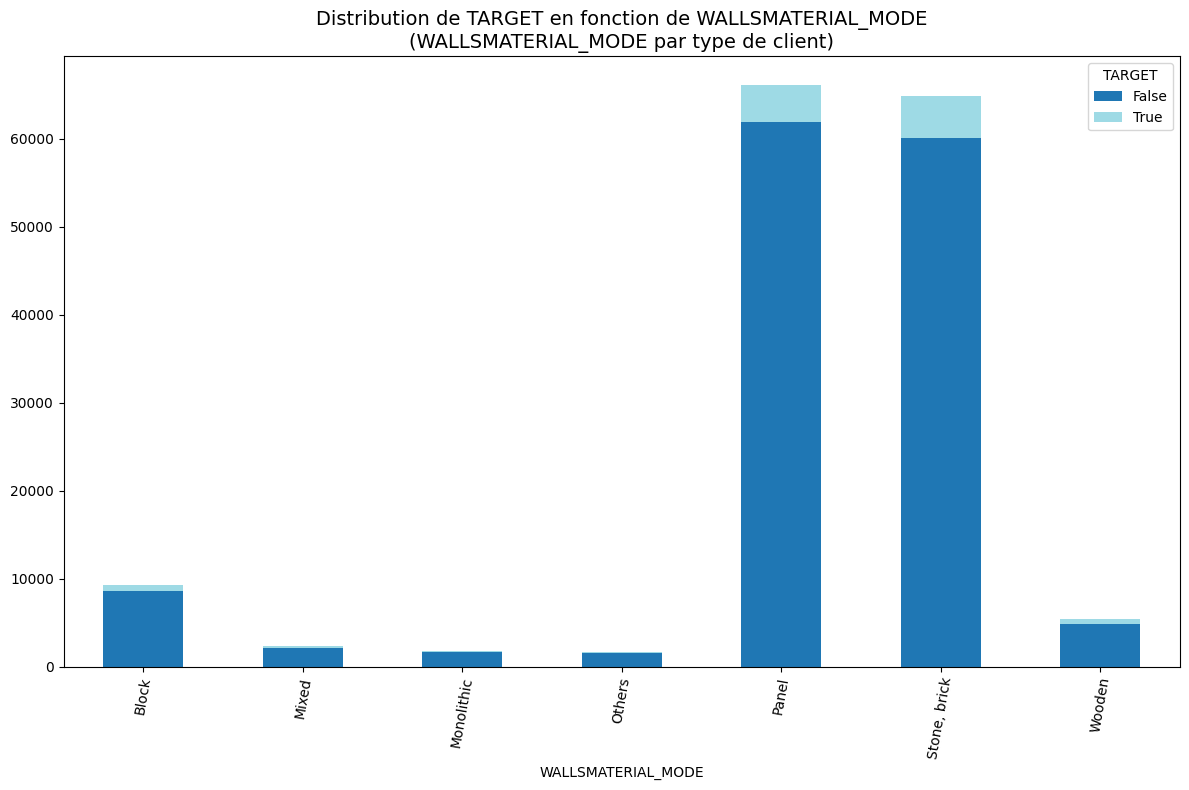

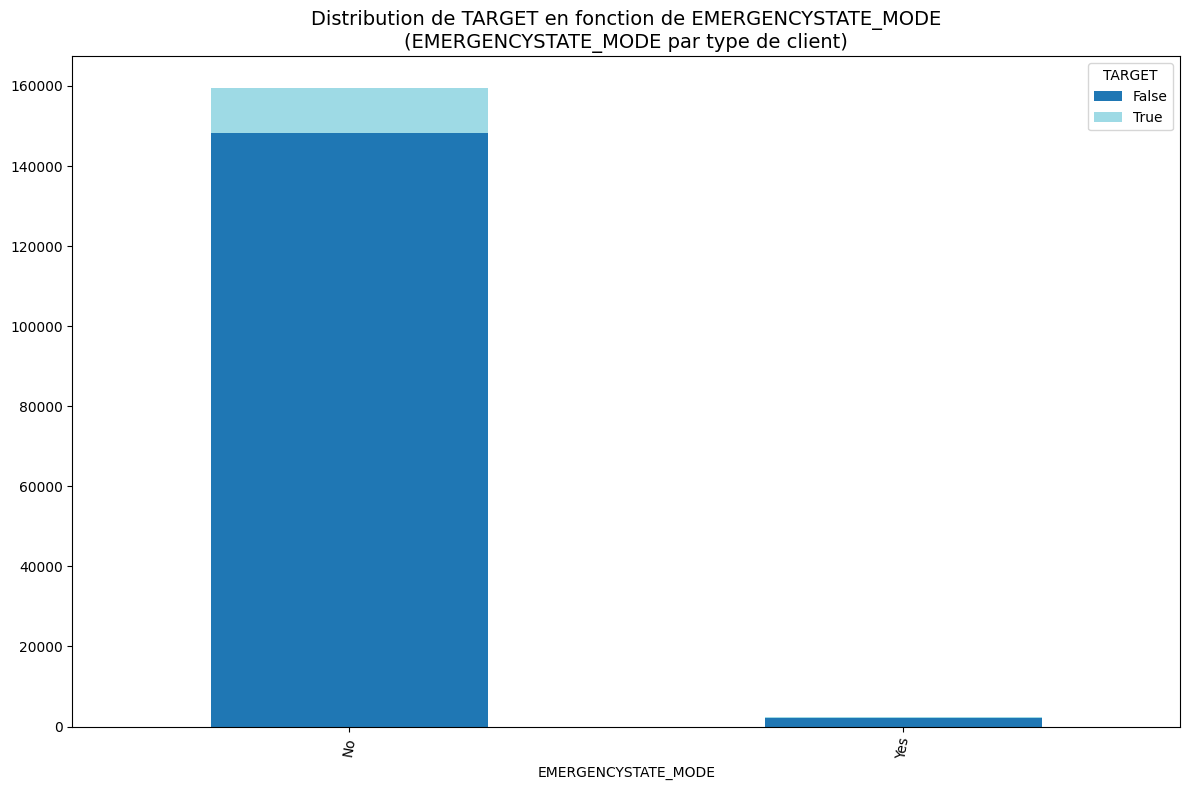

In [27]:
# Distribution des variables qualitatives en fonction de la cible
plots = [
    ('NAME_CONTRACT_TYPE', 'TARGET', "Contrat par type de client"),
    ('CODE_GENDER', 'TARGET', "Genre par type de client"),
    ('FLAG_OWN_CAR', 'TARGET', "Possession d'une voiture par type de client"),
    ('FLAG_OWN_REALTY', 'TARGET', "Possession d'un bien immobilier par type de client"),
    ('NAME_TYPE_SUITE', 'TARGET', "Accompagnants par type de client"),
    ('NAME_INCOME_TYPE', 'TARGET', "Ressources financières par type de client"),
    ('NAME_EDUCATION_TYPE', 'TARGET', "Niveau d'éducation par type de client"),
    ('NAME_FAMILY_STATUS', 'TARGET', "Statut familial par type de client"),
    ('NAME_HOUSING_TYPE', 'TARGET', "Type de logement par type de client"),
    ('OCCUPATION_TYPE', 'TARGET', "Métier par type de client"),
    ('WEEKDAY_APPR_PROCESS_START', 'TARGET', "Jours de demande par type de client"),
    ('ORGANIZATION_TYPE', 'TARGET', "Type d'entreprise par type de client"),
    ('FONDKAPREMONT_MODE', 'TARGET', "FONDKAPREMONT_MODE par type de client"),
    ('HOUSETYPE_MODE', 'TARGET', "Type de logement par type de client"),
    ('WALLSMATERIAL_MODE', 'TARGET', "WALLSMATERIAL_MODE par type de client"),
    ('EMERGENCYSTATE_MODE', 'TARGET', "EMERGENCYSTATE_MODE par type de client"),]

for x, y, title in plots:
    crosstab = pd.crosstab(app_train_clean[x], app_train_clean[y])
    crosstab.plot(kind="bar", stacked=True, figsize=(12, 8), colormap="tab20")
    
    plt.title(f"Distribution de {y} en fonction de {x}\n({title})", fontsize=14)
    plt.xticks(rotation=80)
    plt.tight_layout()
    plt.show()

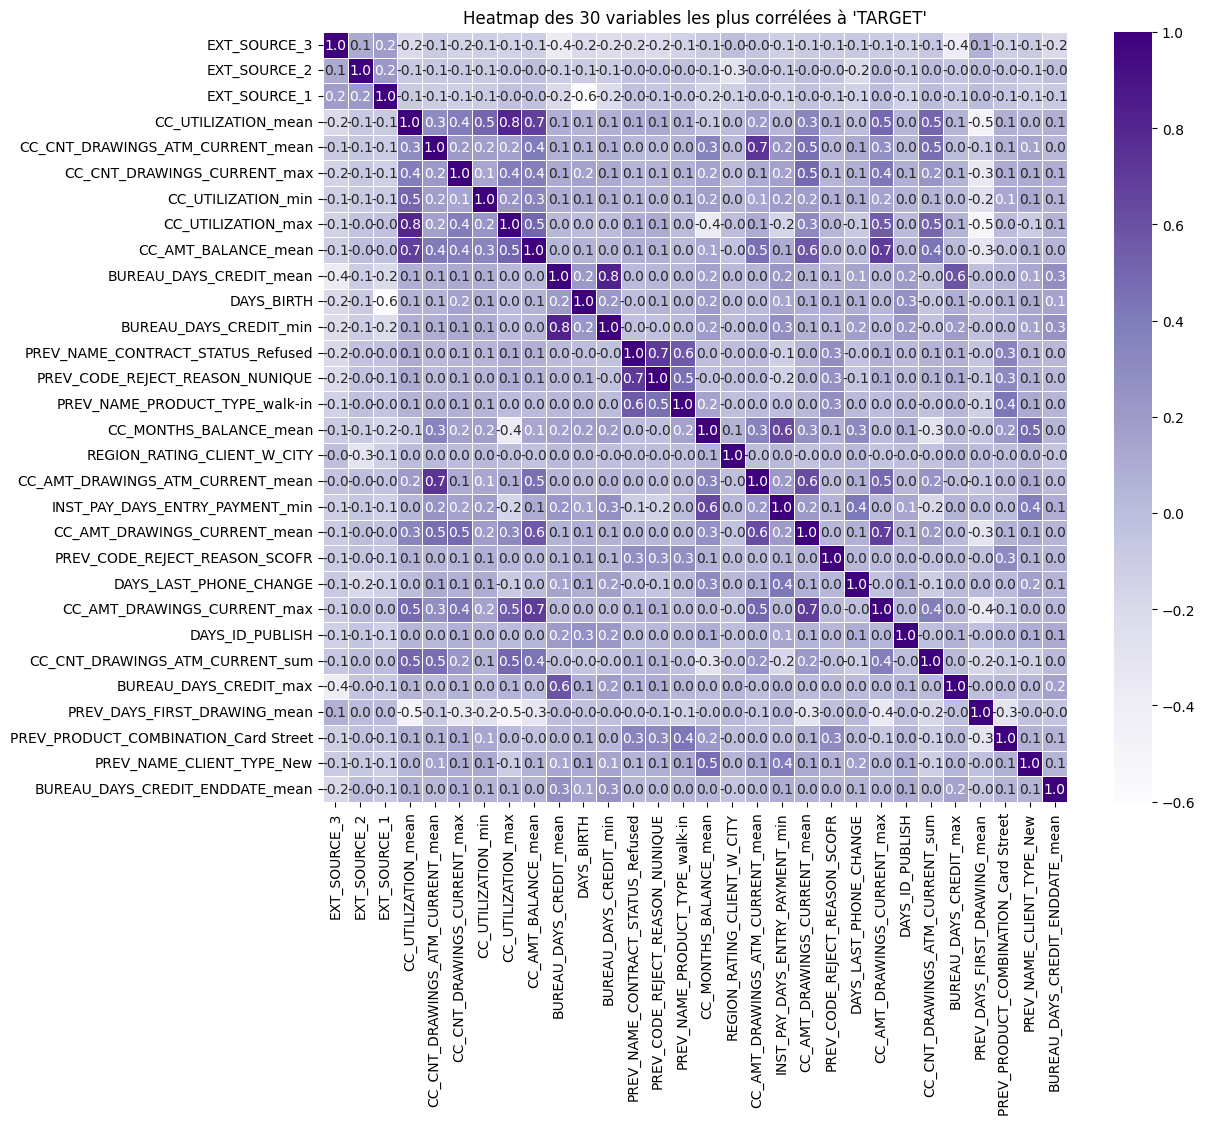

In [28]:
# Matrice des corrélations variables les plus correlées avec la cible
corr_matrix = df_num[top_variables].corr()
    
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="Purples", fmt=".1f", linewidths=0.7)
plt.title(f"Heatmap des {n} variables les plus corrélées à 'TARGET'")
plt.show()

In [30]:
joblib.dump(app_train_clean, "../data/app_train_clean_v2.joblib") 
joblib.dump(app_test_clean, "../data/app_test_clean_v2.joblib")

['../data/app_test_clean_v2.joblib']